In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator, AutoLocator
from scipy.stats import gaussian_kde

In [2]:
from symmetry_utils import RotFlipInvariants, findCanonicalForm, generate_augmented_versions
from pmf_analysis import analyze_pmf_regions
from plotting_utils import plot_training_history, set_clean_style, update_params,visualize_hex
update_params()

### <span style="background-color:cyan">Pruned Dataset Processing </span>

In [3]:
surface = np.load("data_final/feature/surface.npy")
polymer = np.load("data_final/feature/polymer.npy")
pmf_data1 = np.load("data_final/target/pmf_surface.npy")
xdata = np.load("xdata.npy")
ydata = np.load("ydata.npy")
pmf_data = ydata.reshape(92,92,100)

### <span style="background-color:#ff9d3a">**Figure_2 (b)**</span>

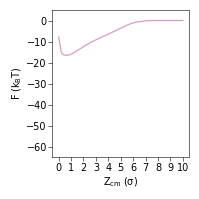

In [4]:
def plot_pmf(pmf_data, selected_surfaces, selected_polymers, x_data=None, colors=None, save_path=None):
    """
    Function to plot PMF data for selected surfaces and polymers.
    
    Parameters: list of surfaces/plymers index
    """
    if x_data is None:
        x_data = np.linspace(0, 10, 100)
    
    if colors is None:
        # ['#d83034','#21A685','#8d1f17', '#ff9d3a', "#E0E417",'#0b81a2','#81CA6A',"#FF6F61","#FFB000","#4D4D4D","#1f3b4d", 'g'] 
        # colors = ['#d83034','#21A685','#8d1f17', '#ff9d3a', "#E0E417",'#0b81a2','#81CA6A',"#FF6F61","#FFB000","#4D4D4D","#1f3b4d", 'g'] 
        colors = ['#D385B0','#E8A314','#5295C9','#098B5A']
    
    plt.figure(figsize=(2, 2))
    
    for idx, surface_idx in enumerate(selected_surfaces):
        surf = round(surface_idx/91,1)
        for polymer_idx in selected_polymers:  
            polymer_ = round(polymer_idx/91,1)
            label = rf'$S_{{{surf}}}, P_{{{polymer_}}}$'
            plt.plot(x_data, pmf_data[surface_idx, polymer_idx], color=colors[0],  #[selected_polymers.index(polymer_idx)]
                     alpha=0.8, linewidth=0.9)
    
    plt.xlabel(r'$\mathrm{Z_{cm} \;(\sigma)}$')
    plt.ylabel(r'$ F (k_{B}T)$')
    plt.ylabel(r'$\mathrm{F\;(k_B T)}$')
    ax = plt.gca()
    # ax.xaxis.set_major_locator(ticker.MultipleLocator(2));ax.yaxis.set_major_locator(ticker.MultipleLocator(10))  
    # ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5));ax.yaxis.set_minor_locator(ticker.MultipleLocator(2))  
    # ax.set_ylim(-60,10)
    # ax.set_ylim(0,60)
    # ax.tick_params(axis='both', direction='in', length=10, width=1, colors='black', pad=8, which='major')
    # ax.tick_params(axis='both', direction='in', length=5, width=1, colors='black', pad=8, which='minor')
    # ax.spines['bottom'].set_linewidth(1); ax.spines['left'].set_linewidth(1)
    # ax.spines['top'].set_linewidth(1); ax.spines['right'].set_linewidth(1)
    # for label in ax.get_xticklabels() + ax.get_yticklabels():
        # label.set_fontsize(12)
        # label.set_fontweight('medium')
    # set_clean_style(ax,major_ticks_x=60,minor_ticks_x=60,major_ticks_y=60,minor_ticks_y=20,minor_tick=None)
    ax = plt.gca()  
    set_clean_style(ax,major_ticks_x=1,major_ticks_y=10,minor_tick=None)
    ax.set_xlabel(r'$\mathrm{Z_{cm} \;(\sigma)}$')
    ax.set_ylabel(r'$\mathrm{F\;(k_B T)}$')
    # ax.set_xlim([4.3,10.4])
    ax.set_ylim([-65,5])
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='pdf',dpi=600, transparent=True, bbox_inches='tight', pad_inches=0.1)
    else:
        plt.show()

# for i in range(5,90,10):
    
selected_surfaces =  [25]
selected_polymers = [5]#[5,35,65,90]
plot_pmf(pmf_data, selected_surfaces, selected_polymers, save_path=None)

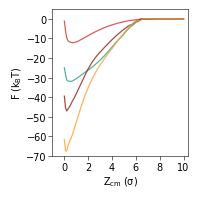

In [5]:
# x_data = np.linspace(4.5,10.4, 100)
x_data = np.linspace(0, 10, 100)
colors = ['#d83034','#21A685','#8d1f17', '#ff9d3a', "#E0E417",'#0b81a2','#81CA6A',"#FF6F61","#FFB000","#4D4D4D","#1f3b4d", 'g']
plt.figure(figsize=(2, 2))
plt.plot(x_data, pmf_data[6,15], color=colors[0],alpha=0.8, linewidth=0.9)
plt.plot(x_data, pmf_data[26,35], color=colors[1],alpha=0.8, linewidth=0.9)
plt.plot(x_data, pmf_data[56,65], color=colors[2],alpha=0.8, linewidth=0.9)
plt.plot(x_data, pmf_data[76,85], color=colors[3],alpha=0.8, linewidth=0.9)

ax = plt.gca()  
set_clean_style(ax,major_ticks_x=2,major_ticks_y=10,minor_tick=None)
ax.set_xlabel(r'$\mathrm{Z_{cm} \;(\sigma)}$')
ax.set_ylabel(r'$\mathrm{F\;(k_B T)}$')
ax.set_xlim([-1,10.4])
ax.set_ylim([-70,5])
plt.tight_layout()
plt.savefig("plots_siba/pmf_plots_new/pmf_plot_fig2_a.pdf", dpi=400, bbox_inches='tight',transparent=True)
# plt.show() 

In [6]:
results = analyze_pmf_regions(pmf_data)
del_F = results["delF"]
del_F.shape

(92, 92)

### <span style="background-color:#ff9d3a">**Figure_2 (d)**</span>

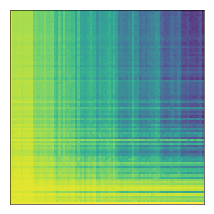

In [7]:
from matplotlib import colors

delF = np.min(pmf_data,axis=2)
delF_skip = delF[1:,1:]

fig = plt.figure(figsize=(2.15, 2.15))
cmap = plt.cm.viridis
im = plt.imshow(delF, origin="lower", aspect="auto",alpha=0.9,interpolation='nearest',cmap=cmap)
ax = plt.gca()
set_clean_style(ax)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_xticks([])
ax.set_yticks([])
# ax.set_xlabel(r"$f_{A_s}$")
# ax.set_ylabel(r"$f_{A_p}$")
# fractions = np.linspace(0, 1, delF.shape[0])  # 92 fractions
# ticks = np.arange(0,1.01, 0.2)  # [0.0, 0.2, ..., 1.0]
# tick_positions = [np.argmin(np.abs(fractions - t)) for t in ticks]

# ax.set_xticks(tick_positions)
# ax.set_xticklabels([f"{t:.1f}" for t in ticks])
# ax.set_yticks(tick_positions)
# ax.set_yticklabels([f"{t:.1f}" for t in ticks])
# cbar = fig.colorbar(im, ax=ax, shrink=0.4, pad=0.03,aspect=7)
# cbar.ax.set_ylabel(r"$\Delta F (k_{B}T)$")
# cbar.ax.tick_params(labelsize=4)
fig.tight_layout()
# fig.savefig("plots_siba/pmf_plots_new/pol_surf_delF_fig2_e.pdf", dpi=400, bbox_inches='tight',transparent=True)
plt.show()

In [10]:
# ##############
# ###Delta F####
# ##############
delF_matrix = np.min(pmf_data,axis=2)
# Reshape to [polymer, surface]
# delF_matrix = delF.reshape(92, 92)

# Polymer bins without 0.0
polymer_bins = {
    0.0 :[0],
    0.1: list(range(1, 11)),
    0.2: list(range(11, 21)),
    0.3: list(range(21, 31)),
    0.4: list(range(31, 41)),
    0.5: list(range(41, 51)),
    0.6: list(range(51, 61)),
    0.7: list(range(61, 71)),
    0.8: list(range(71, 81)),
    0.9: list(range(81, 91)),
    1.0: [91]
}

# Collect ΔF distributions
y_list = []
fractions = []  # keep track of composition fractions
for frac, idx in polymer_bins.items():
    group_data = delF_matrix[idx, :].flatten()
    y_list.append(group_data)
    fractions.append(frac)


y_00 = y_list[0]
y_01 = y_list[1]
y_02 = y_list[2]
y_03 = y_list[3]
y_04 = y_list[4]
y_05 = y_list[5]
y_06 = y_list[6]
y_07 = y_list[7]
y_08 = y_list[8]
y_09 = y_list[9]
y_10 = y_list[10]

### <span style="background-color:#ff9d3a">**Violin plot-Figure_2 (d) inset**</span>

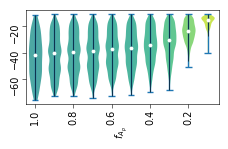

In [11]:
from matplotlib.cm import get_cmap
def adjacent_values(vals, q1, q3):
    upper_adjacent_value = q3 + (q3 - q1) * 1.5
    upper_adjacent_value = np.clip(upper_adjacent_value, q3, vals[-1])

    lower_adjacent_value = q1 - (q3 - q1) * 1.5
    lower_adjacent_value = np.clip(lower_adjacent_value, vals[0], q1)
    return lower_adjacent_value, upper_adjacent_value


y = [y_01.flatten(),y_02.flatten(),y_03.flatten(),y_04.flatten(),y_05.flatten(),y_06.flatten(),y_07.flatten(),y_08.flatten(),y_09.flatten(),y_10.flatten()]

plt.figure(figsize=(2.3,1.5)) #2.5,1.5 for polymer 
norm = plt.Normalize(vmin=np.min(delF), vmax=np.max(delF))
cmap = cm.viridis
medians = [np.median(vals) for vals in y]  # your violin slices
colors = [cmap(norm(m)) for m in medians]
vplot = plt.violinplot(y,vert=True,widths=0.7)
for patch, color in zip(vplot['bodies'],colors):
    patch.set_facecolor(color)
    patch.set_edgecolors('black')
    patch.set_alpha(0.8)
    patch.set_linewidth(0)
plt.gca().set_xticks(np.arange(0,11),labels=[f"{i/10:.1f}" for i in range(11)])
quartiles = []
medians = []
whiskers = []

for data1 in y:
    sorted_data = np.sort(data1)
    q1, median, q3 = np.percentile(sorted_data, [25, 50, 75])
    quartiles.append((q1, q3))
    medians.append(median)
    whiskers.append(adjacent_values(sorted_data, q1, q3))

quartiles = np.array(quartiles)
medians = np.array(medians)
whiskers = np.array(whiskers)

quartile1, quartile3 = quartiles[:, 0], quartiles[:, 1]
whiskers_min, whiskers_max = whiskers[:, 0], whiskers[:, 1]

# Print results
# print("Quartile 1 (Q1):", quartile1)
# print("Medians:", medians)
# print("Quartile 3 (Q3):", quartile3)
# print("Whiskers Min:", whiskers_min)
# print("Whiskers Max:", whiskers_max)
inds = np.arange(1, len(medians) + 1)
plt.scatter(inds, medians, marker='o', color='white', s=3, zorder=3)
# plt.vlines(inds, quartile1, quartile3, color='k', linestyle='-', lw=4,alpha=0.6)
plt.vlines(inds, whiskers_min, whiskers_max, color='k', linestyle='-', lw=0.5,alpha=0.8)
ax = plt.gca()
set_clean_style(ax,major_ticks_x=2,
    major_ticks_y=20,
    minor_tick=None,
)
for spine in ax.spines.values():
    spine.set_linewidth(0.6) 
    spine.set_alpha(0.7)       
ax.tick_params(axis='x', labelrotation=90)
ax.tick_params(axis='y', labelrotation=90)

ax.set_xlim(10.5,0.4)
# ax.set_xlabel(r"$f_{A_s}$")
ax.set_xlabel(r"$f_{A_p}$",rotation=90)
ax.xaxis.labelpad = 1
ax.yaxis.labelpad = 1
# ax.set_xlabel(r"Fraction")
# plt.savefig("plots_siba/pmf_plots_new/violin_polymer.pdf", dpi=400, bbox_inches='tight',transparent=True)
plt.show()

In [12]:
def morans_I(surface):
    """
    Compute Moran's I for a 2D binary surface (20x20).
    Returns:
        MoranI : float
    """
    surface = np.array(surface, dtype=float)
    N = surface.shape[0]
    x = surface.flatten()
    Npix = len(x)
    mean_x = x.mean()
    var = np.sum((x - mean_x)**2)

    # 4-neighbor adjacency
    w = 0
    num = 0
    for i in range(N):
        for j in range(N):
            idx = i*N + j
            for di,dj in [(1,0),(-1,0),(0,1),(0,-1)]:
                ni, nj = i+di, j+dj
                if 0 <= ni < N and 0 <= nj < N:
                    nidx = ni*N + nj
                    w += (x[idx] - mean_x) * (x[nidx] - mean_x)
                    num += 1

    MoranI = (Npix / num) * (w / var) if var > 0 else 0
    return MoranI

morans_array = np.array([morans_I(surf) for surf in surface])  # shape (92,)
morans_expanded = np.repeat(morans_array[:, None], del_F.shape[1], axis=1)

# Flatten
morans_flat = morans_expanded.flatten()
delF_flat   = del_F.flatten()

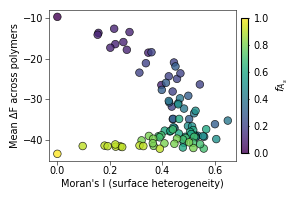

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Example: surfaces shape (92, 20, 20), delF shape (92, 92)
N = surface.shape[0]
delF = np.min(pmf_data,axis=2)
# 1. Compute Moran's I for each surface
moran_array = np.array([morans_I(surface[i]) for i in range(N)])

# 2. Compute mean ΔF across polymers for each surface
mean_delF_per_surface = delF.mean(axis=1)   # shape (92,)

# 3. Compute composition (fraction of strong beads = 0s)
fractions = (surface == 0).reshape(N, -1).mean(axis=1)

# 4. Scatter plot with fraction-based color
plt.figure(figsize=(3,2))
sc = plt.scatter(moran_array, mean_delF_per_surface,
                 c=fractions, cmap="viridis", s=30, alpha=0.8,edgecolors="k",linewidths=0.5)


# plt.title("Relation between surface heterogeneity & binding free energy", fontsize=13)


ax = plt.gca()
set_clean_style(ax,major_ticks_x=0.2,major_ticks_y=10)
ax.set_xlabel("Moran's I (surface heterogeneity)")
ax.set_ylabel("Mean ΔF across polymers")
cbar = plt.colorbar(sc,ax=ax, shrink=0.9, pad=0.02)
cbar.set_label(r"$f_{A_s}$", fontsize=8)
# plt.savefig("plots_siba/pmf_plots_new/moranI_polymer_fig2_c.pdf", dpi=400, bbox_inches='tight',transparent=True)
plt.show()

### <span style="background-color:#ff9d3a">**Figure-2 (e)**</span> 

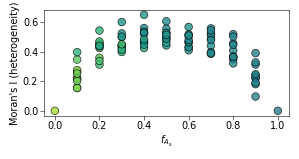

In [14]:
# fractions = (surface == 0).reshape(surface.shape[0], -1).mean(axis=1)

# from sklearn.cluster import KMeans
# import matplotlib.pyplot as plt
# import numpy as np
# plt.figure(figsize=(3,2))
# X = np.column_stack([fractions, moran_array])

# # cluster into groups (say 5 clusters)
# kmeans = KMeans(n_clusters=5, random_state=0).fit(X)
# labels = kmeans.labels_

# # plot
# plt.scatter(fractions, moran_array,  s=30, alpha=0.8,edgecolors="k",linewidths=0.5)
# ax = plt.gca()
# set_clean_style(ax,major_ticks_x=0.2,major_ticks_y=0.2)
# plt.xlabel(r"$f_{A_s}$")
# plt.ylabel("Moran's I (heterogeneity)")
# # plt.colorbar(label="Cluster")
# plt.show()
# plt.savefig("plots_siba/pmf_plots_new/moranI_surface_fig2_d.pdf", dpi=400, bbox_inches='tight',transparent=True)
N = surface.shape[0]
delF = np.min(pmf_data,axis=2)
# 1. Compute Moran's I for each surface
moran_array = np.array([morans_I(surface[i]) for i in range(N)])

# 2. Compute mean ΔF across polymers for each surface
mean_delF_per_surface = delF.mean(axis=1)   # shape (92,)

# 3. Compute composition (fraction of strong beads = 0s)
fractions = (surface == 0).reshape(N, -1).mean(axis=1)

plt.figure(figsize=(3,1.6))
# plt.figure(figsize=(7,3))
X = np.column_stack([fractions, moran_array])

# color points by mean ΔF
sc = plt.scatter(fractions, moran_array,
                 c=mean_delF_per_surface, cmap="viridis",
                 s=30, alpha=0.8, edgecolors="k", linewidths=0.5,vmin=-75, vmax=0)

ax = plt.gca()
set_clean_style(ax, major_ticks_x=0.2, major_ticks_y=0.2)
ax.set_xlabel(r"$f_{A_s}$")
ax.set_ylabel("Moran's I (heterogeneity)")

# add colorbar for ΔF
# cbar = plt.colorbar(sc, ax=ax, shrink=0.9, pad=0.02)
# cbar.set_label("Mean ΔF across polymers", fontsize=8)


# plt.savefig("plots_siba/pmf_plots_new/moranI_surface_fig2_d.pdf", dpi=400, bbox_inches='tight', transparent=True)
plt.show()
# print(surface[0])
# mean_delF_per_surface.shape
# delF[60,:].mean()

In [15]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import product

def MarkovianChain(sequence_list,n):
    count_arr = np.zeros((2,) * n)
    for seq in sequence_list:
        for ind in range(len(seq) - n):
            index_tuple = tuple(int(bit) for bit in seq[ind:ind+n])
            count_arr[index_tuple] +=1
            # reversed_tuple = tuple(int(bit) for bit in reversed(seq[ind:ind+n]))
            # count_arr[reversed_tuple] +=1
            # print(f"forward-{index_tuple}, reverse-{reversed_tuple}")
            # Another way
            # index_tuple = tuple(int(bit) for bit in seq[ind:ind+n])
            # count_arr[index_tuple] += 1/2
            # count_arr[reversed(index_tuple)] += 1/2
            # Note count_arr need not be of type integer always as we have to average over the fd and rev seq
            
    return count_arr

# print(polymer_temp[11:13,:])
# MarkovianChain(polymer_temp[11:13,:],4)
sequence_ = ['000100110', '1100110001', '1110001110', '0001001101']
count_ = MarkovianChain(sequence_[0], 4)

# print(count_)

def normalize_matrix(matrix, mode):
    if mode == "count":
        return matrix
    elif mode == "global":
        return matrix / matrix.sum()
    elif mode == "row_wise":
        sum_row = matrix.sum(axis=1,keepdims=True)
        return np.divide(matrix, sum_row, where= sum_row != 0)
    else:
        return None
    

def visualize_high_order_markov_matrix(transition_matrix):
    """
    Visualizes an even n-dimensional Markov transition matrix as a 2**(n/2) x 2**(n/2) heatmap.

    Args:
        transition_matrix (np.array): An n-dimensional transition matrix (n even).
    """
    size = 2**transition_matrix.ndim  # Should be 2^n
    heatmap_size = 2**(transition_matrix.ndim // 2)
    n = transition_matrix.ndim
    half_n = int(n/2)  # Order of the Markov chain (even number)
    
    assert n % 2 == 0, "This visualization only works for even n."
    
    states = [''.join(map(str, bits)) for bits in product([0, 1], repeat=half_n)]  # Generate phase space of all "half_n"-bit states
    
    # Assign sorted phase space in both x and y axes
    x_labels = sorted(states)
    y_labels = sorted(states)

    # Reshape the transition matrix into a 2^(n/2) x 2^(n/2) matrix
    reshaped_matrix = transition_matrix.reshape((heatmap_size , heatmap_size))

    normalized_matrix = normalize_matrix(reshaped_matrix, mode="global") ## siba
    # We need global mode for normalised count when we look at prevalence, row wise mode will give transition probability
    
    # Plot the heatmap
    fig = plt.figure(figsize=(1.5,1.5))
    
    sns.heatmap(normalized_matrix, annot=True, fmt=".4f",cmap='viridis',
                xticklabels=x_labels, yticklabels=y_labels,linewidths=0.5, vmin=0, vmax=0.4,annot_kws={"size": 5})
    ax = plt.gca()
    set_clean_style(ax,major_ticks_x=0.05,major_ticks_y=0.05)
    ax.tick_params(axis='both', direction='out', length=0, width=0.4, colors='black', pad=4, which='major')

    # plt.xlabel(f"Last {half_n}-bit State",fontsize=14, fontweight='bold')
    # plt.ylabel(f"First {half_n}-bit State",fontsize=14, fontweight='bold')
    #plt.title(f"{n}-Order Markov Chain Transition Matrix (Heatmap)")
    # plt.title(f"{n}-Order Sub-sequence Prevalence")
    # plt.xticks(rotation=None, ha="right", fontsize=12)
    # plt.yticks(fontsize=12)
    #plt.show() # Don't use show() method if you want to save figure to a path

    return fig

## More statistics

(2, 2)


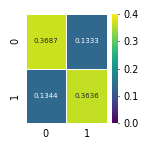

In [16]:
n = 2  # Can be any even number
count_matrix = MarkovianChain(polymer,n)
print(count_matrix.shape)
#print(count_matrix)
#print(count_matrix[1,0,0,0])
fig = visualize_high_order_markov_matrix(count_matrix)
# plt.savefig("plots_siba/pmf_plots_new/transition_matrix.pdf", dpi=400, bbox_inches='tight',transparent=True)
plt.show()

#### <span style="background-color:#ff9d3a">**Distribution of $\Delta F$ (with fraction $f_{A_{s}}$ and $f_{A_{p}}$ )**</span>

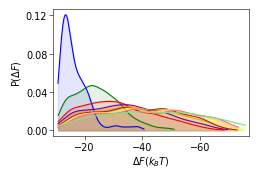

In [17]:
fractions = np.linspace(0.1, 1.0, 10)
colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'yellow','pink', '#FF6F61',"#7AE582"]
plt.figure(figsize=(2.6, 1.8)) 

for i, (frac, color) in enumerate(zip(fractions, colors)):
    var_name = f"y_{i+1:02d}" 
    if var_name in globals():  
        data = globals()[var_name]

        kde = gaussian_kde(data)
        x_vals = np.linspace(np.min(data), np.max(data), 1000)
        plt.plot(x_vals, kde(x_vals), label=fr"$f = {frac:.1f}$", color=color,linewidth=0.8)
        plt.fill_between(x_vals, kde(x_vals),color=color,alpha=0.1)

ax = plt.gca()
ax.set_xlim([-9,-77])
# ax.set_ylim([0,0.24])
set_clean_style(ax,major_ticks_x=20,major_ticks_y=0.04)
ax.set_xlabel(r'$ \Delta F (k_{B}T)$')
ax.set_ylabel(r"P($ \Delta F $)")
# plt.savefig("plots_siba/pmf_plots_new/distDelF_surface_fig2_f.pdf", dpi=400, bbox_inches='tight',transparent=True)
# plt.savefig("plots_siba/AI4MAT/figure_3a.pdf", dpi=400, bbox_inches='tight',transparent=True)
plt.show()

In [18]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.stats import gaussian_kde

# def plot_distribution(data, title, color='blue', highlights=None, save=False):
#     """
#     Plots the KDE.

#     """
#     x_vals = np.linspace(np.min(data), np.max(data), 1000)
#     kde = gaussian_kde(data.flatten())

#     plt.figure(figsize=(6, 4))
#     plt.plot(x_vals, kde(x_vals), 'k-', alpha=1)
#     # plt.axvline(np.mean(data.flatten()), color='r', linestyle='--')
#     plt.fill_between(x_vals, kde(x_vals), alpha=0.2, color=color)
#     if highlights:
#         for start, end, color in highlights:
#             plt.axvspan(start, end, alpha=0.2, color=color)
    
#     # plt.fill_between(30,50,alpha=0.3, color='red')

#     plt.xlabel(r"$ \Delta F~(kT)$")
#     plt.ylabel("Frequency")

#     ax = plt.gca()
#     ax.tick_params(axis='both', direction='in', length=8, width=1, colors='black', pad=8, which='major')
    
    
#     ax.spines['bottom'].set_linewidth(1.5)
#     ax.spines['left'].set_linewidth(1.5)
#     ax.spines['top'].set_linewidth(1.5)
#     ax.spines['right'].set_linewidth(1.5)
#     plt.tight_layout()
#     if save:
#         plt.savefig(save, dpi=300,bbox_inches='tight')

#     plt.show()
# plot_distribution(del_F,"del F",highlights=[(8,25,"gray"),(25,50,"red"),(50,70,"green")],save="plots_siba/distribution_DelF.pdf")

## Distribution of $\Delta F$ and its First, Second Derivative

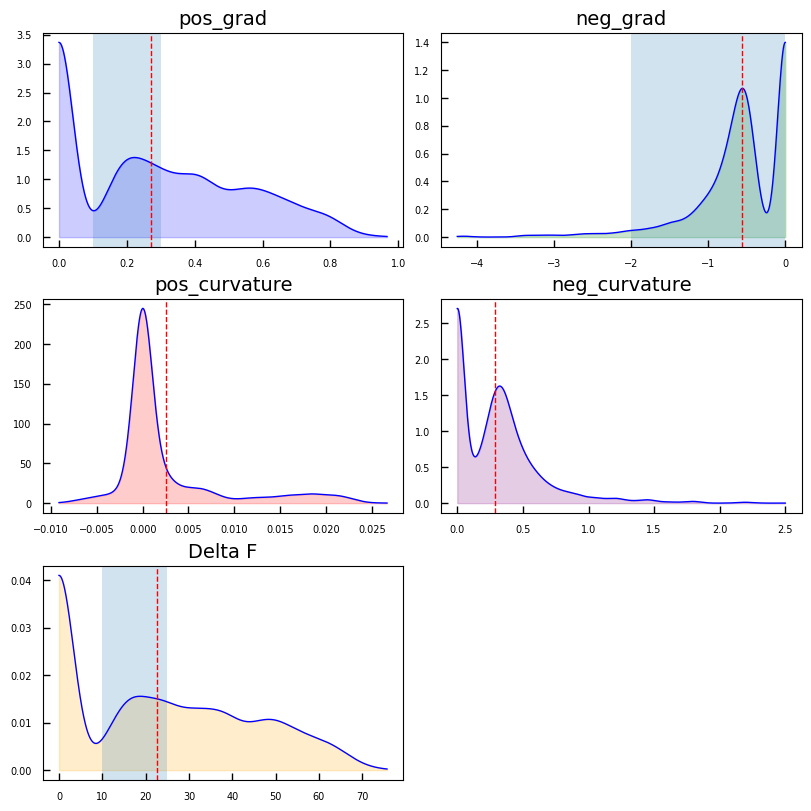

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


data_dict = {
    "pos_grad": results["positive_gradient"],
    "neg_grad": results["negative_gradient"],
    "pos_curvature": results["positive_curvature"],
    "neg_curvature": results["negative_curvature"],
    "Delta F": del_F
}

highlight_regions = {
    "pos_grad": (0.1, 0.3),
    "neg_grad": (-2, 0),
    "Delta F": (10, 25)
}

fig, axs = plt.subplots(3, 2, layout='constrained', figsize=(8, 8))
axs = axs.flatten()  


for i, (title, data) in enumerate(data_dict.items()):
    x_vals = np.linspace(np.min(data), np.max(data), 1000)
    kde = gaussian_kde(data.flatten())
    
    ax = axs[i]
    ax.plot(x_vals, kde(x_vals), 'b-', alpha=1)
    ax.axvline(np.mean(data.flatten()), color='r', linestyle='--')
    ax.fill_between(x_vals, kde(x_vals), alpha=0.2, color=colors[i])

    ax.set_title(title)
    ax.tick_params(axis='both', direction='in', length=5, width=1, colors='black', pad=8, which='major')

    
    if title in highlight_regions:
        ax.axvspan(*highlight_regions[title], alpha=0.2)


axs[-1].axis("off")

# plt.savefig("plots_siba/distribution.png", dpi=300)
plt.show()


### <span style="background-color:#ff9d3a">**Figure_S2**</span>

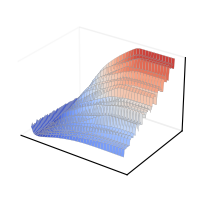

In [20]:
def get_surface_range(fraction_index, fraction_sizes):
    if fraction_index < 0 or fraction_index >= len(fraction_sizes):
        raise ValueError(
            f"fraction_index must be in [0, {len(fraction_sizes)-1}]"
        )

    surf_start = sum(fraction_sizes[:fraction_index])
    surf_end   = surf_start + fraction_sizes[fraction_index]
    return surf_start, surf_end

from matplotlib import cm
from matplotlib.colors import Normalize

PMF = pmf_data1

fraction_index = 10
surfaces_per_fraction = 10

num_polymers = PMF.shape[1]
pmf_bins = PMF.shape[2]


fraction_sizes = [1] + [10]*9 + [1]

surf_start, surf_end = get_surface_range(fraction_index, fraction_sizes)

fig = plt.figure(figsize=(2, 2))
ax = fig.add_subplot(111, projection="3d")

x = np.arange(pmf_bins)
y = np.arange(num_polymers)
X, Y = np.meshgrid(x, y)

norm = Normalize(
    vmin=np.min(PMF[surf_start:surf_end]),
    vmax=np.max(PMF[surf_start:surf_end])
)

cmap = cm.coolwarm

for s in range(surf_start, surf_end):

    Z = PMF[s]

    ax.plot_surface(
        X,
        Y,
        Z,
        cmap=cmap,
        norm=norm,
        rstride=2,
        cstride=3,
        edgecolor= (0.6, 0.6, 0.6, 1.0),  
        linewidth=0.15,            
        antialiased=True,
        alpha=1.0
    )

ax.view_init(elev=28, azim=-55)
ax.set_box_aspect((1.4, 1.1, 0.9))

for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.pane.fill = False

ax.grid(False)
ax.tick_params(labelsize=9)
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.set_zlim(0, 75)
# sm = cm.ScalarMappable(norm=norm, cmap=cmap)
# sm.set_array([])
# cbar = plt.colorbar(sm, shrink=0.65, pad=0.08)
# cbar.set_label("ΔF", fontsize=10)
plt.tight_layout()
# fig.savefig(f"plots_siba/SI/pmf_3d_{fraction_index}.pdf", transparent=True,dpi=300,bbox_inches='tight')

plt.show()


### 3D surface plo of $\Delta F$

/tmp/ipykernel_2870280/2410703982.py:71: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


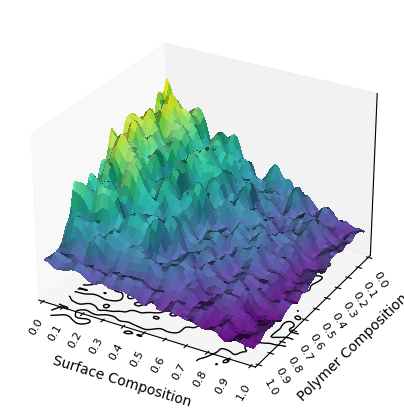

In [21]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import LightSource
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
from matplotlib import colors, cm
import matplotlib as mpl
fig = plt.figure(figsize=(5, 5))
avg_pmf_data = del_F.reshape(92*92,1)

surface_comps = np.linspace(0, 1, 92)
polymer_comps = np.linspace(0, 1, 92)
X, Y = np.meshgrid(surface_comps, polymer_comps)

smoothed_pmf = gaussian_filter(avg_pmf_data[::-1], sigma=0.5)

points = np.column_stack((X.ravel(), Y.ravel()))
values = smoothed_pmf.ravel()

xi = np.linspace(1, 0, 100)   
yi = np.linspace(0, 1, 100)
XI, YI = np.meshgrid(xi, yi)
ZI = griddata(points, values, (XI, YI), method='linear')
ZI = gaussian_filter(ZI, sigma=2)
ls = LightSource(azdeg=60, altdeg=85)
rgb = ls.shade(ZI, cmap=plt.cm.viridis, vert_exag=0.05, blend_mode='soft')#mpl.colormaps['YlOrRd']
norm = colors.Normalize(vmin=np.percentile(ZI, 5), vmax=np.percentile(ZI, 99))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(XI, YI, ZI,
                       facecolors=rgb,
                       alpha=1,
                       linewidth=0,
                       antialiased=False,
                       rstride=2, cstride=2)
# contour = ax.contourf(XI, YI, ZI, zdir='z', offset=ZI.min() - 12.0, norm=norm,cmap='plasma',
                      # alpha=0.9,linewidths=1.0, color='k',levels=100)  # thickness of contour lines
ax.contour(XI, YI, ZI, zdir='z', offset=ZI.min() - 12.0,linewidths=1.0, colors='k')                    
ax.set_xlabel("Surface Composition",fontsize=10)
ax.set_ylabel("Polymer Composition",fontsize=10)
# ax.set_zlabel(r"$\Delta F$ (kJ/mol)",fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=7,pad=0)
ax.tick_params(axis='z', which='both', length=0, labelsize=0)
ax.set_zticks([])  
for label in ax.get_xticklabels():
    label.set_rotation(60)

for label in ax.get_yticklabels():
    label.set_rotation(300)
ax.set_xlim(1, 0)
ax.set_ylim(0, 1)
ax.set_zlim(0,70)
ax.xaxis.set_major_locator(MultipleLocator(0.1))
ax.yaxis.set_major_locator(MultipleLocator(0.1))
ax.grid(False)
ax.xaxis.set_visible(False)
ax.view_init(elev=28, azim=120)
fig.patch.set_alpha(0)  # Transparent background for the figure
ax.set_facecolor('none')
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontsize(8)
    label.set_fontweight('medium')
# ax.minorticks_on()
# fig.colorbar(surf, shrink=0.5, aspect=5,anchor=(0,0.9)) 
mappable = plt.cm.ScalarMappable(norm=norm, cmap=plt.cm.viridis)
mappable.set_array([])  # required for older versions of matplotlib

# Add colorbar
# cbar = fig.colorbar(mappable, ax=ax, shrink=0.4, pad=0.2)
# cbar.ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()
# fig.savefig('plots_siba/delF_3dplot.pdf', transparent=True,dpi=600,bbox_inches='tight')

### Box Plot of $\Delta F$

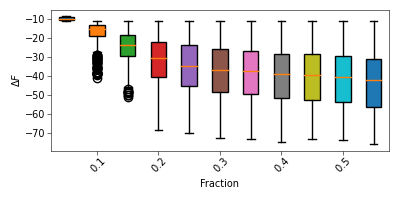

In [32]:
##########################
###Box plot of Delta F ###
##########################
from matplotlib.cm import get_cmap
colors = [plt.cm.tab10(i/9) for i in range(10)]
y = [y_00.flatten(),y_01.flatten(),y_02.flatten(),y_03.flatten(),y_04.flatten(),y_05.flatten(),y_06.flatten(),y_07.flatten(),y_08.flatten(),y_09.flatten(),y_10.flatten()]
plt.figure(figsize=(4,2))
bplot = plt.boxplot(y,labels=[f" {i/10:.1f}" for i in range(11)],patch_artist=True)
for patch, color in zip(bplot['boxes'],colors):
    patch.set_facecolor(color)
plt.xticks(rotation=45)
plt.ylabel(r"$  \Delta F$")
# plt.xlabel()
ax = plt.gca()
set_clean_style(ax,major_ticks_x=2,major_ticks_y=10,minor_tick=None)
ax.set_xlabel(r"Fraction")
# plt.legend()
# plt.savefig('plots_siba/Box_plot_polymer.pdf',dpi=300)
plt.show()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 76.00it/s]


0.0 75.750226
0 5576


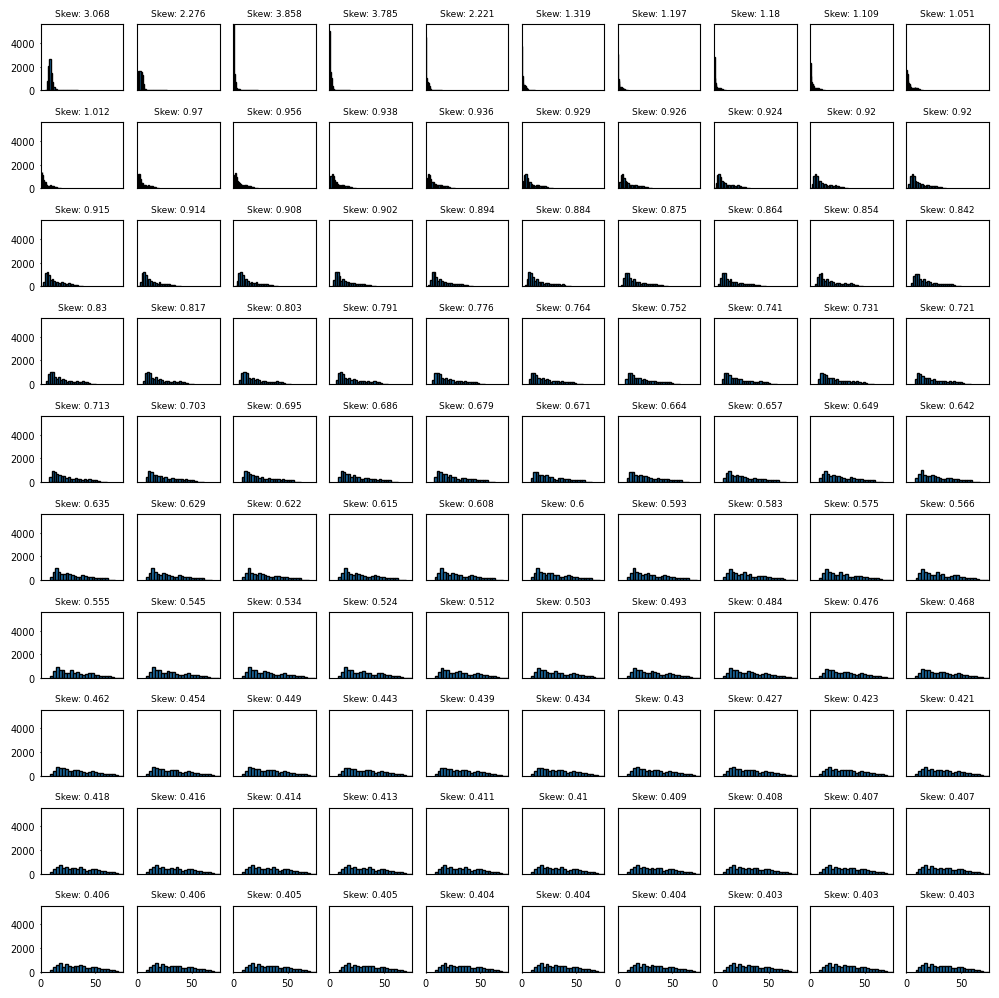

In [48]:
def set_dynamic_title(ax, title, padding=0.01):
    bbox = ax.get_position()
    width = bbox.width
    height = bbox.height
    font_size = min(width, height) * 100  
    ax.set_title(title, fontsize=font_size)
from tqdm import tqdm
from scipy.stats import skew
fig, axes = plt.subplots(10, 10, figsize=(10, 10)) 

ymax = -np.inf
ymin = np.inf

xmax = -np.inf
xmin = np.inf

for i in tqdm(range(100)):

  temp_data = pmf_data1.reshape(-1,100)[:,i]

  counts, bin_edges = np.histogram(temp_data, bins=25)
  bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0

  xmax = max(xmax,max(bin_edges))
  xmin = min(xmin,min(bin_edges))

  ymax = max(ymax,max(counts))
  ymin = min(ymin,min(counts))

  ax = axes[int(i/10),i%10]
  ax.bar(bin_centers, counts, width=np.diff(bin_edges), edgecolor='black', align='center')
  title = "Skew: "+str(np.round(skew(temp_data),3))
  set_dynamic_title(ax, title)

print(xmin, xmax)
print(ymin, ymax)

for i in range(10):
  for j in range(10):
    ax = axes[i, j]

    ax.set_xlim((xmin,xmax))
    ax.set_ylim((ymin,ymax))
    if j != 0:  
      ax.tick_params(left=False, labelleft=False)
    if i != 9:  
      ax.tick_params(bottom=False, labelbottom=False)

plt.tight_layout()
plt.show()

### 